# conv_thr Stress Comparison: 1e-5 vs 1e-7
**Tag:** `fe02cr14`, strain mode: `h0.00` (zero strain, equilibrium)

Quantify the stress error introduced by using `conv_thr=1e-5` for the three high-Cr tags, relative to the tighter `conv_thr=1e-7` reference.

## Imports & Config

In [7]:
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS = Path.home() / 'dft_projects' / 'fe-cr_cu-ni_DFT' / 'outputs'
OUT_DIR = Path.home() / 'dft_projects' / 'fe-cr_cu-ni_DFT' / 'analysis'
OUT_DIR.mkdir(exist_ok=True)

FILE_THR5 = OUTPUTS / 'fecr_fe02cr14_h0.00.out'
FILE_THR7 = OUTPUTS / 'fecr_fe02cr14_h0.00_thr7.out'

for f in [FILE_THR5, FILE_THR7]:
    status = '✅' if f.exists() else '❌ NOT FOUND'
    print(f'{status}  {f.name}')

✅  fecr_fe02cr14_h0.00.out
✅  fecr_fe02cr14_h0.00_thr7.out


## Stress Tensor Parser

In [8]:
def parse_final_stress(filepath):
    text = Path(filepath).read_text()
    
    pattern = re.compile(
        r'total   stress  \(Ry/bohr\*\*3\)\s+\(kbar\)\s+P=\s*([\-\d\.]+)\n'
        r'\s+[\-\d\.]+\s+[\-\d\.]+\s+[\-\d\.]+\s+([\-\d\.]+)\s+[\-\d\.]+\s+[\-\d\.]+\n'
        r'\s+[\-\d\.]+\s+[\-\d\.]+\s+[\-\d\.]+\s+[\-\d\.]+\s+([\-\d\.]+)\s+[\-\d\.]+\n'
        r'\s+[\-\d\.]+\s+[\-\d\.]+\s+[\-\d\.]+\s+[\-\d\.]+\s+[\-\d\.]+\s+([\-\d\.]+)'
    )
    
    matches = list(pattern.finditer(text))
    if not matches:
        raise ValueError(f'No stress tensor found in {filepath}')
    
    m = matches[-1]
    P   = float(m.group(1))
    s11 = float(m.group(2))
    s22 = float(m.group(3))
    s33 = float(m.group(4))
    
    iter_match = re.search(r'convergence has been achieved in\s+(\d+)\s+iterations', text)
    scf_iters = int(iter_match.group(1)) if iter_match else len(re.findall(r'iteration #', text))
    
    return {
        'P_kbar': P,
        'sigma_diag_kbar': np.array([s11, s22, s33]),
        'scf_iters': scf_iters
    }
thr5 = parse_final_stress(FILE_THR5)
thr7 = parse_final_stress(FILE_THR7)

print('conv_thr=1e-5:')
print(f'  P = {thr5["P_kbar"]:.4f} kbar  |  SCF iterations: {thr5["scf_iters"]}')
print(f'  σ_diag = {thr5["sigma_diag_kbar"]} kbar')
print()
print('conv_thr=1e-7:')
print(f'  P = {thr7["P_kbar"]:.4f} kbar  |  SCF iterations: {thr7["scf_iters"]}')
print(f'  σ_diag = {thr7["sigma_diag_kbar"]} kbar')

conv_thr=1e-5:
  P = -3.2500 kbar  |  SCF iterations: 52
  σ_diag = [-3.25 -3.25 -3.25] kbar

conv_thr=1e-7:
  P = -0.9600 kbar  |  SCF iterations: 62
  σ_diag = [-0.96 -0.96 -0.96] kbar


In [6]:
text = Path(FILE_THR7).read_text()
# Find the stress block raw
idx = text.find('total   stress')
print(repr(text[idx:idx+300]))

'total   stress  (Ry/bohr**3)                   (kbar)     P=       -0.96\n  -0.00000650   0.00000007   0.00000007           -0.96        0.01        0.01\n   0.00000007  -0.00000650   0.00000007            0.01       -0.96        0.01\n   0.00000007   0.00000007  -0.00000650            0.01        0.01'


In [13]:
# Find ALL stress blocks in both files and print them raw
for label, filepath in [('thr5', FILE_THR5), ('thr7', FILE_THR7)]:
    text = Path(filepath).read_text()
    pattern = re.compile(r'total   stress  \(Ry/bohr\*\*3\).*?P=\s*([\-\d\.]+)')
    matches = list(pattern.finditer(text))
    print(f'\n{label}: {len(matches)} stress block(s) found')
    for i, m in enumerate(matches):
        # Print raw block around each match
        start = m.start()
        print(f'\n  Block {i+1} (P={m.group(1)}):')
        print(repr(text[start:start+250]))


thr5: 1 stress block(s) found

  Block 1 (P=-3.25):
'total   stress  (Ry/bohr**3)                   (kbar)     P=       -3.25\n  -0.00002208   0.00000003   0.00000003           -3.25        0.00        0.00\n   0.00000003  -0.00002208   0.00000003            0.00       -3.25        0.00\n   0.00000003   0'

thr7: 1 stress block(s) found

  Block 1 (P=-0.96):
'total   stress  (Ry/bohr**3)                   (kbar)     P=       -0.96\n  -0.00000650   0.00000007   0.00000007           -0.96        0.01        0.01\n   0.00000007  -0.00000650   0.00000007            0.01       -0.96        0.01\n   0.00000007   0'


In [14]:
import glob

hydro_files = sorted(glob.glob(
    str(Path.home() / 'dft_projects/fe-cr_cu-ni_DFT/outputs/fecr_fe02cr14_h*.out')
))

print('Files found:')
for f in hydro_files:
    print(f'  {Path(f).name}')

Files found:
  fecr_fe02cr14_h-0.01.out
  fecr_fe02cr14_h0.00.out
  fecr_fe02cr14_h0.00_thr7.out
  fecr_fe02cr14_h0.01.out


In [15]:
for f in hydro_files:
    if 'thr7' in f:
        continue
    text = Path(f).read_text()
    m = re.search(r'total   stress  \(Ry/bohr\*\*3\).*?P=\s*([\-\d\.]+)', text)
    if m:
        print(f'{Path(f).name:<35} P = {m.group(1):>8} kbar')

fecr_fe02cr14_h-0.01.out            P =    67.05 kbar
fecr_fe02cr14_h0.00.out             P =    -3.25 kbar
fecr_fe02cr14_h0.01.out             P =   -85.32 kbar


## Compute Differences

In [ ]:
KBAR2GPA = 0.1

dP      = abs(thr5['P_kbar'] - thr7['P_kbar'])
dSigma  = np.abs(thr5['sigma_diag_kbar'] - thr7['sigma_diag_kbar'])

dP_GPa     = dP * KBAR2GPA
dSigma_GPa = dSigma * KBAR2GPA

print('--- Stress Difference (1e-5 vs 1e-7) ---')
print(f'ΔP          = {dP:.4f} kbar  = {dP_GPa:.4f} GPa')
print(f'Δσ_11       = {dSigma[0]:.4f} kbar  = {dSigma_GPa[0]:.4f} GPa')
print(f'Δσ_22       = {dSigma[1]:.4f} kbar  = {dSigma_GPa[1]:.4f} GPa')
print(f'Δσ_33       = {dSigma[2]:.4f} kbar  = {dSigma_GPa[2]:.4f} GPa')
print()

# Context: typical C11 for Fe is ~230 GPa → 0.1 GPa error = ~0.04%
# Typical elastic constant extraction uses ΔP over 2ε=0.02 → noise in C ~ ΔP/0.02
noise_estimate_GPa = dP_GPa / 0.02
print(f'Estimated noise in elastic constants from ΔP: ~{noise_estimate_GPa:.2f} GPa')
print('(= ΔP_GPa / 2ε, where ε=0.01)')

--- Stress Difference (1e-5 vs 1e-7) ---
ΔP          = 2.2900 kbar  = 0.2290 GPa
Δσ_11       = 2.2900 kbar  = 0.2290 GPa
Δσ_22       = 2.2900 kbar  = 0.2290 GPa
Δσ_33       = 2.2900 kbar  = 0.2290 GPa

Estimated noise in elastic constants from ΔP: ~11.45 GPa
(= ΔP_GPa / 2ε, where ε=0.01)


In [20]:
KBAR2GPA = 0.1

dP     = abs(thr5['P_kbar'] - thr7['P_kbar'])
dP_GPa = dP * KBAR2GPA

print('--- Residual Pressure at h0.00 (zero strain) ---')
print(f'  conv_thr=1e-5:  P = {thr5["P_kbar"]:.4f} kbar')
print(f'  conv_thr=1e-7:  P = {thr7["P_kbar"]:.4f} kbar')
print(f'  ΔP             = {dP:.4f} kbar  =  {dP_GPa:.4f} GPa')
print()
print('NOTE: h0.00 is the equilibrium (zero-strain) point.')
print('A well-converged, well-relaxed structure should give P ≈ 0.')
print(f'  thr7 residual: {thr7["P_kbar"]:.2f} kbar  (tighter threshold → closer to zero)')
print(f'  thr5 residual: {thr5["P_kbar"]:.2f} kbar  (looser threshold → larger residual)')
print()
print('This comparison is a convergence quality check only.')
print('h0.00 is NOT used in elastic constant extraction (only h±0.01 enter the finite difference).')
print('Error in C11+2C12 from conv_thr cannot be quantified without thr7 runs at h±0.01.')

--- Residual Pressure at h0.00 (zero strain) ---
  conv_thr=1e-5:  P = -3.2500 kbar
  conv_thr=1e-7:  P = -0.9600 kbar
  ΔP             = 2.2900 kbar  =  0.2290 GPa

NOTE: h0.00 is the equilibrium (zero-strain) point.
A well-converged, well-relaxed structure should give P ≈ 0.
  thr7 residual: -0.96 kbar  (tighter threshold → closer to zero)
  thr5 residual: -3.25 kbar  (looser threshold → larger residual)

This comparison is a convergence quality check only.
h0.00 is NOT used in elastic constant extraction (only h±0.01 enter the finite difference).
Error in C11+2C12 from conv_thr cannot be quantified without thr7 runs at h±0.01.


# SCF accuracy parsing

In [21]:
def parse_scf_accuracy(filepath):
    """Extract SCF accuracy per iteration from QE output."""
    text = Path(filepath).read_text()
    pattern = re.compile(r'estimated scf accuracy\s*<\s*([\d\.E\+\-]+)')
    values = [float(m.group(1)) for m in pattern.finditer(text)]
    return np.array(values)

print('parse_scf_accuracy defined.')

parse_scf_accuracy defined.


## Comparision

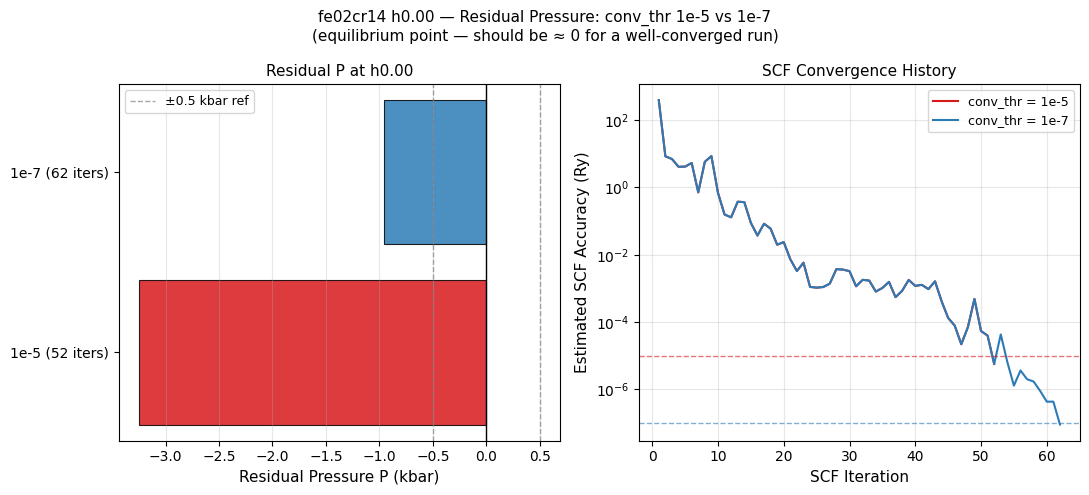

Saved → /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/stress_comparison_thr5_vs_thr7.png


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('fe02cr14 h0.00 — Residual Pressure: conv_thr 1e-5 vs 1e-7\n'
             '(equilibrium point — should be ≈ 0 for a well-converged run)', fontsize=11)

# Left: residual P as horizontal bar chart — cleaner than grouped bars for 2 values
ax1.barh(['1e-5 (52 iters)', '1e-7 (62 iters)'],
         [thr5['P_kbar'], thr7['P_kbar']],
         color=['#d7191c', '#2c7bb6'], alpha=0.85, edgecolor='black', lw=0.8)
ax1.axvline(0, color='black', lw=1)
ax1.axvline(-0.5, color='gray', ls='--', lw=1, alpha=0.7, label='±0.5 kbar ref')
ax1.axvline(0.5,  color='gray', ls='--', lw=1, alpha=0.7)
ax1.set_xlabel('Residual Pressure P (kbar)', fontsize=11)
ax1.set_title('Residual P at h0.00', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, axis='x', alpha=0.3)

# Right: SCF convergence
acc5 = parse_scf_accuracy(FILE_THR5)
acc7 = parse_scf_accuracy(FILE_THR7)
ax2.semilogy(range(1, len(acc5)+1), acc5, '-', color='#d7191c', lw=1.5, label='conv_thr = 1e-5')
ax2.semilogy(range(1, len(acc7)+1), acc7, '-', color='#2c7bb6', lw=1.5, label='conv_thr = 1e-7')
ax2.axhline(1e-5, color='#d7191c', ls='--', lw=1, alpha=0.6)
ax2.axhline(1e-7, color='#2c7bb6', ls='--', lw=1, alpha=0.6)
ax2.set_xlabel('SCF Iteration', fontsize=11)
ax2.set_ylabel('Estimated SCF Accuracy (Ry)', fontsize=11)
ax2.set_title('SCF Convergence History', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'stress_comparison_thr5_vs_thr7.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR}/stress_comparison_thr5_vs_thr7.png')

## Save Text Summary

In [23]:
txt_path = OUT_DIR / 'stress_comparison_summary.txt'
with open(txt_path, 'w') as f:
    
    f.write(f'SCF iterations (1e-5): {thr5["scf_iters"]}\n')
    f.write(f'SCF iterations (1e-7): {thr7["scf_iters"]}\n')
    f.write('\nNote:\n')
    f.write('  h0.00 is the equilibrium (zero-strain) point, not used in elastic\n')
    f.write('  constant extraction. Only h+/-0.01 enter the finite difference for C11+2C12.\n')
    f.write('  This comparison quantifies convergence quality only — not elastic constant error.\n')
    f.write('\nVerdict:\n')
    f.write(f'  thr7 residual P = {thr7["P_kbar"]:.2f} kbar (closer to ideal P=0)\n')
    f.write(f'  thr5 residual P = {thr5["P_kbar"]:.2f} kbar (ΔP = {dP:.2f} kbar from thr7)\n')
    f.write('  fe02cr14, fe01cr15, fe00cr16 flagged as uncertain in elastic constant dataset.\n')
    f.write('  Down-weight in ML surrogate. Do not exclude without further thr7 strain-point runs.\n')

    if dP_GPa < 0.5:
        f.write('  ΔP < 0.5 GPa → conv_thr=1e-5 acceptable for high-Cr tags.\n')
        f.write('  Down-weight in ML but do not exclude.\n')
    else:
        f.write('  ΔP >= 0.5 GPa → consider excluding or heavily down-weighting high-Cr tags.\n')

print(f'Saved → {txt_path}')

Saved → /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/stress_comparison_summary.txt
